In [6]:
import pandas as pd, matplotlib, matplotlib.pyplot as plt, xarray as xr, datetime, regionmask
from functools import reduce

matplotlib.rcParams['savefig.bbox'] = "tight"    # always save with tight bounding box

ERROR 1: PROJ: proj_create_from_database: Open of /rds/general/user/cb2714/home/miniforge3/envs/wwa/share/proj failed


In [12]:
sa = regionmask.defined_regions.natural_earth_v5_1_2.countries_50.to_geodataframe().loc[[67]]

In [ ]:
sa.bounds

In [ ]:
xn,xx,yn,yx = [34,56,16,33]

<Axes: >

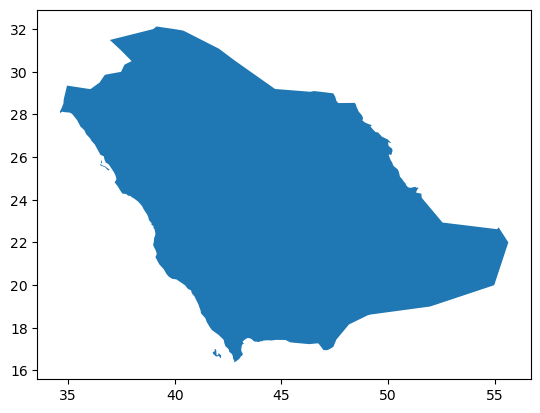

In [18]:
sa.clip((xn,yn,xx,yx)).plot()

In [42]:
# ! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O gmst.txt

--2026-05-20 10:20:38--  https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4762 (4.7K)
Saving to: ‘gmst.txt’

gmst.txt            100%[===================>]   4.65K  --.-KB/s    in 0s      

2026-05-20 10:20:39 (42.7 MB/s) - ‘gmst.txt’ saved [4762/4762]



In [7]:
t2m_h = pd.read_csv("era5-land_t2m-hourly_39.8_21.4.csv", index_col = "valid_time", parse_dates = ["valid_time"])[["t2m"]]
t2m_h["t2m"] = t2m_h.t2m - 273.15

In [8]:
tmax = t2m_h.resample("D").max()
tmin = t2m_h.resample("D").min()
tmean = t2m_h.resample("D").mean()

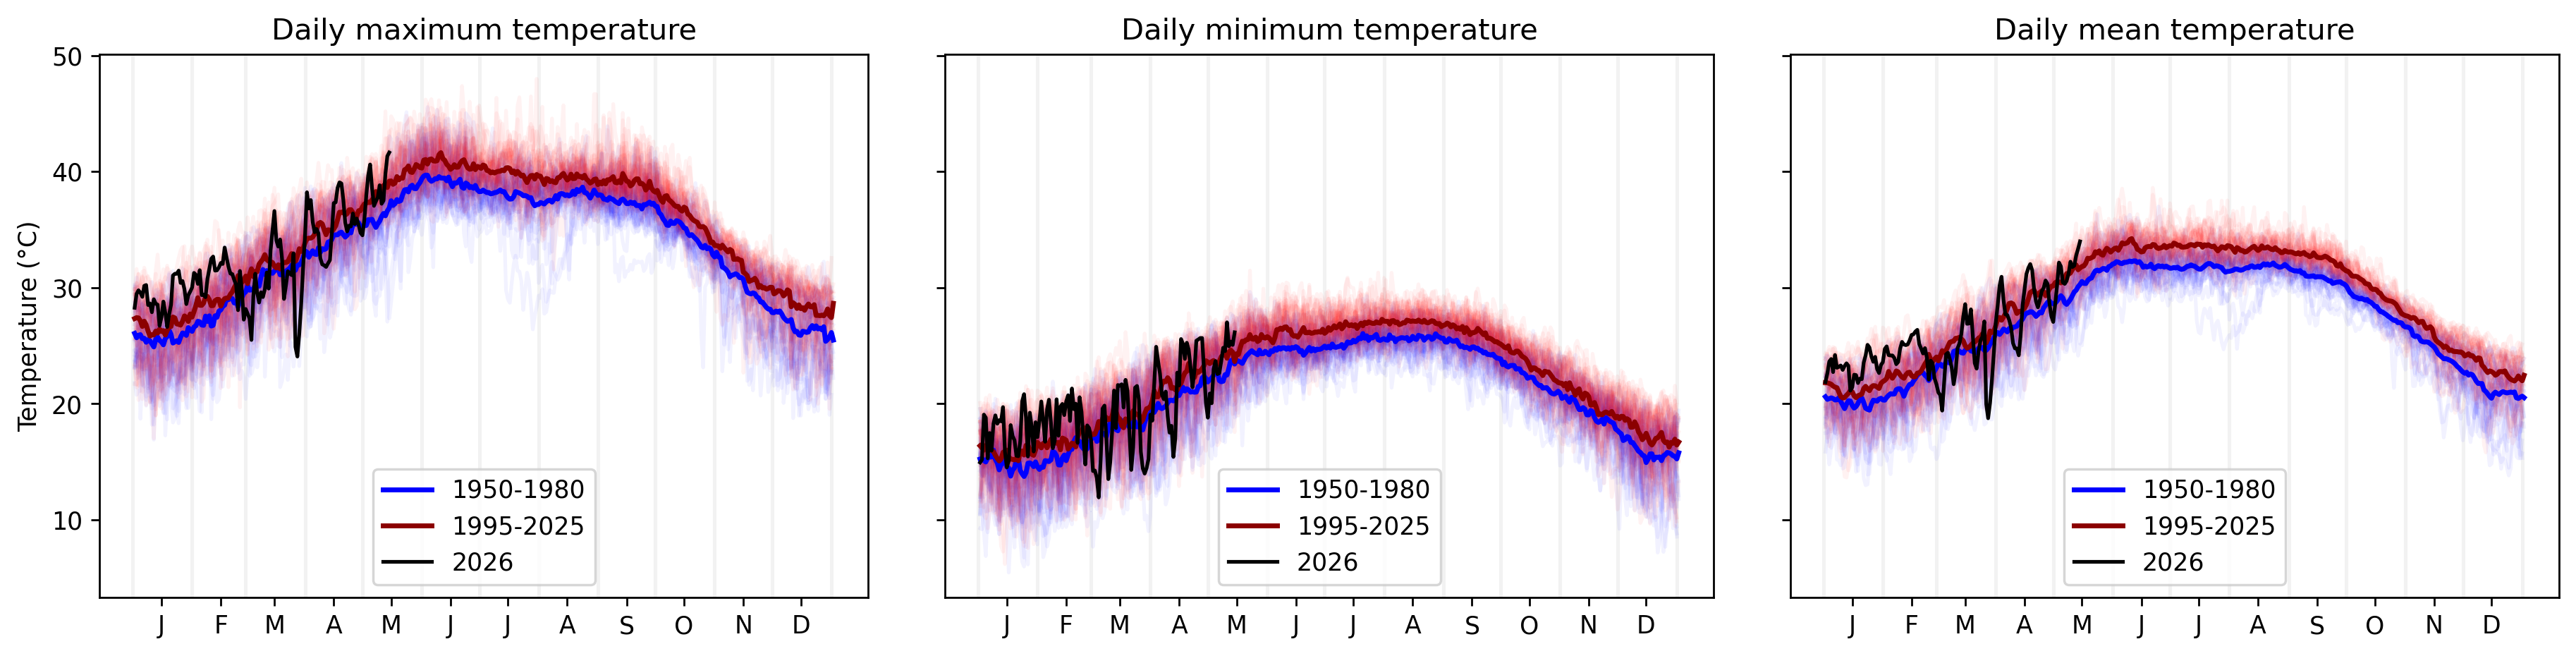

In [18]:
nc = 3

hist = slice("1950", "1980")
pres = slice("1995", "2025")
fc_start = "2026-05-15"

days = pd.date_range(start = "2026-01-01", end = "2027-01-01")
labelticks = [i+1 for i in range(len(days)) if (days[i].day) == 15]
labels = [days[i].strftime("%b")[0] for i in range(len(days)) if (days[i].day) == 15]

fig, axs = plt.subplots(ncols = nc, figsize = (nc * 6,4), dpi = 250, sharey = True)
plt.subplots_adjust(wspace = 0.1)
if nc == 1: axs = [axs]

for i in range(nc):
    
    ax = axs[i]
    ts = [tmax, tmin, tmean][i]
    ttl = "Daily "+["maximum", "minimum", "mean"][i]+" temperature"
    
    ts.loc[hist].groupby(ts.loc[hist].index.dayofyear).mean().plot(ax = ax, color = "blue", lw = 2, label = hist.start+"-"+hist.stop, zorder = 99)
    ts.loc[pres].groupby(ts.loc[pres].index.dayofyear).mean().plot(ax = ax, color = "darkred", lw = 2, label = pres.start+"-"+pres.stop, zorder = 99)
    
    ts.loc[slice("2026-01", fc_start)].groupby(ts.loc[slice("2026-01", fc_start)].index.dayofyear).mean().plot(ax = ax, color = "k", zorder = 99)
    ts.loc[slice(fc_start, None)].groupby(ts.loc[slice(fc_start, None)].index.dayofyear).mean().plot(ax = ax, color = "k", ls = ":", zorder = 99)
    
    for y in range(int(hist.start), int(hist.stop)+1): 
        ax.plot(ts.loc[str(y)].index.dayofyear, ts.loc[str(y)], color = "blue", alpha = 0.05, label = "_")
    
    for y in range(int(pres.start), int(pres.stop)+1): 
        ax.plot(ts.loc[str(y)].index.dayofyear, ts.loc[str(y)], color = "red", alpha = 0.05, label = "_")
    
    ax.set_xticks(labelticks)
    ax.set_xticklabels(labels)
    [ax.axvline(x, color = "k", alpha = 0.05) for x in range(len(days)) if (days[x].day) == 1]
    
    ax.set_xlabel("")
    ax.set_ylabel("Temperature (°C)")

    ax.set_title(ttl)
    
    ax.legend([hist.start+"-"+hist.stop, pres.start+"-"+pres.stop, "2026"])

plt.savefig("fig_seasonal-cycle.png")

In [10]:
monmean = tmean.resample("MS").mean()

<Axes: xlabel='valid_time'>

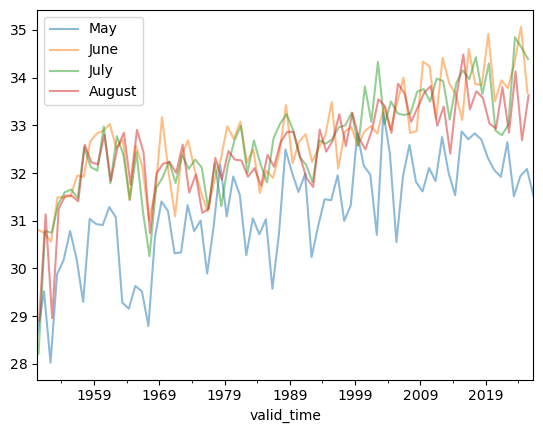

In [19]:
monmean.loc[monmean.index.month == 5].rename(columns = {"t2m" : "May"}).plot(alpha = 0.5)
monmean.loc[monmean.index.month == 6].rename(columns = {"t2m" : "June"}).plot(ax = plt.gca(), alpha = 0.5)
monmean.loc[monmean.index.month == 7].rename(columns = {"t2m" : "July"}).plot(ax = plt.gca(), alpha = 0.5)
monmean.loc[monmean.index.month == 8].rename(columns = {"t2m" : "August"}).plot(ax = plt.gca(), alpha = 0.5)

## Trends in monthly mean temperatures

In [34]:
gmst = pd.read_table("data/gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")

t2m = xr.open_dataset("data/t2m-daily_box_era5.nc").t2m
t2m_monthly = t2m.resample(time = "MS").mean()
t2m_monthly = t2m_monthly.sel(time = slice(None, "2026-05"))

In [35]:
df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), 
            [t2m_monthly.groupby("time.month")[m].rename(str(m)).to_dataframe() for m in [5,6,7,8]])

In [36]:
df = []
for m in [5,6,7,8]:
    df_m = t2m_monthly.groupby("time.month")[m].rename(str(m))
    df_m = df_m.assign_coords(time = df_m.time.dt.year).to_dataframe()
    df.append(df_m)

df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df)

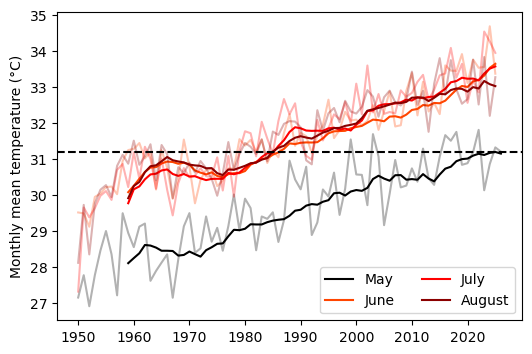

In [37]:
fig, ax = plt.subplots(figsize = (6,4), dpi = 100)

cols = ["k", "orangered", "red", "darkred"]
months = [5,6,7,8]

for i in range(4):
    m = months[i]
    ax.plot(df.index, df[[str(m)]], alpha = 0.3, color = cols[i], label = "_")
    ax.plot(df.index, df[[str(m)]].rolling(10).mean(), alpha = 1, color = cols[i], label = datetime.datetime(2026,m,1).strftime("%B"))
#     df[[str(m)]].rolling(10).mean().plot(ax = ax, alpha = 1, color = cols[i])

ax.axhline(df.loc[slice(2016,None), "5"].mean(), ls = "--", color = "k")

ax.legend(loc = "lower right", ncols = 2)
ax.set_xlabel("")
ax.set_ylabel("Monthly mean temperature (°C)")

plt.savefig("fig/trends-per-month_box_era5_tmean.png")

## Trends in monthly peak temperatures

In [26]:
gmst = pd.read_table("data/gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")

t2m = xr.open_dataset("data/tmax-daily_box_era5.nc").tmax
t2m_monthly = t2m.resample(time = "MS").max()
t2m_monthly = t2m_monthly.sel(time = slice(None, "2026-05"))

In [27]:
df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), 
            [t2m_monthly.groupby("time.month")[m].rename(str(m)).to_dataframe() for m in [5,6,7,8]])

In [28]:
df = []
for m in [5,6,7,8]:
    df_m = t2m_monthly.groupby("time.month")[m].rename(str(m))
    df_m = df_m.assign_coords(time = df_m.time.dt.year).to_dataframe()
    df.append(df_m)

df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df)

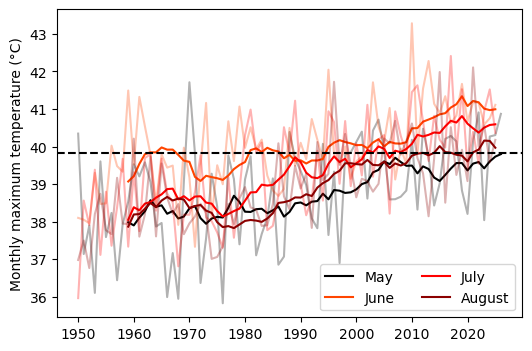

In [29]:
fig, ax = plt.subplots(figsize = (6,4), dpi = 100)

cols = ["k", "orangered", "red", "darkred"]
months = [5,6,7,8]

for i in range(4):
    m = months[i]
    ax.plot(df.index, df[[str(m)]], alpha = 0.3, color = cols[i], label = "_")
    ax.plot(df.index, df[[str(m)]].rolling(10).mean(), alpha = 1, color = cols[i], label = datetime.datetime(2026,m,1).strftime("%B"))
#     df[[str(m)]].rolling(10).mean().plot(ax = ax, alpha = 1, color = cols[i])

ax.axhline(df.loc[slice(2016,None), "5"].mean(), ls = "--", color = "k")

ax.legend(loc = "lower right", ncols = 2)
ax.set_xlabel("")
ax.set_ylabel("Monthly maximum temperature (°C)")

plt.savefig("fig/trends-per-month_box_era5_tx1x.png")

## Trends in nighttime peak temperatures

In [30]:
gmst = pd.read_table("data/gmst.txt", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")

t2m = xr.open_dataset("data/tmin-daily_box_era5.nc").tmin
t2m_monthly = t2m.resample(time = "MS").max()
t2m_monthly = t2m_monthly.sel(time = slice(None, "2026-05"))

In [31]:
df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), 
            [t2m_monthly.groupby("time.month")[m].rename(str(m)).to_dataframe() for m in [5,6,7,8]])

In [32]:
df = []
for m in [5,6,7,8]:
    df_m = t2m_monthly.groupby("time.month")[m].rename(str(m))
    df_m = df_m.assign_coords(time = df_m.time.dt.year).to_dataframe()
    df.append(df_m)

df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df)

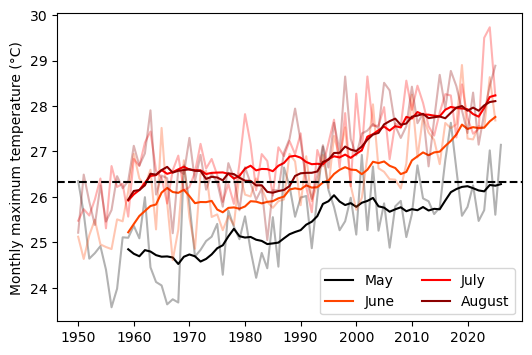

In [33]:
fig, ax = plt.subplots(figsize = (6,4), dpi = 100)

cols = ["k", "orangered", "red", "darkred"]
months = [5,6,7,8]

for i in range(4):
    m = months[i]
    ax.plot(df.index, df[[str(m)]], alpha = 0.3, color = cols[i], label = "_")
    ax.plot(df.index, df[[str(m)]].rolling(10).mean(), alpha = 1, color = cols[i], label = datetime.datetime(2026,m,1).strftime("%B"))
#     df[[str(m)]].rolling(10).mean().plot(ax = ax, alpha = 1, color = cols[i])

ax.axhline(df.loc[slice(2016,None), "5"].mean(), ls = "--", color = "k")

ax.legend(loc = "lower right", ncols = 2)
ax.set_xlabel("")
ax.set_ylabel("Monthly maximum temperature (°C)")

plt.savefig("fig/trends-per-month_box_era5_tn1x.png")

In [15]:
df_ts = []
df_fitted = []
for m in range(5,9):

    ts_m = t2m_monthly.loc[t2m_monthly.index.month == m]
    ts_m.index = ts_m.index.year
    df_ts.append(ts_m.rename(columns = {"t2m" : datetime.datetime(y,m,1).strftime("%B")}))
    
    gmst_m = gmst.loc[ts_m.index]
    da_m = ts_m.to_xarray().t2m.assign_coords(valid_time = gmst_m.gmst.values)
    
    coeffs = da_m.polyfit("valid_time", deg = 1)
    fitted_values = xr.polyval(da_m.valid_time, coeffs).polyfit_coefficients
    fitted_values = fitted_values.assign_coords(valid_time = gmst_m.index.values)
    df_fitted.append(fitted_values.rename("m"+str(m), valid_time = "gmst").to_dataframe())

df_ts = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df_ts)
df_fitted = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df_fitted)
df_fitted.index.name = "valid_time"

AttributeError: 'DataArray' object has no attribute 'index'

In [ ]:
df_ts.plot(alpha = 0.3)
ax = plt.gca()
ax.set_prop_cycle(None)
df_ts.rolling(10, center = False).mean().plot(ax = ax)

ax.set_prop_cycle(None)
ax.axhline(df_ts.loc[slice(2016,None), "May"].mean(), ls = "--")

plt.savefig("fig_monthly-mean-trends.png")

In [15]:
df_ts = []
df_fitted = []
for m in range(1,13):

    ts_m = monmean.loc[monmean.index.month == m]
    ts_m.index = ts_m.index.year
    df_ts.append(ts_m.rename(columns = {"t2m" : datetime.datetime(y,m,1).strftime("%B")}))
    
    gmst_m = gmst.loc[ts_m.index]
    da_m = ts_m.to_xarray().t2m.assign_coords(valid_time = gmst_m.gmst.values)
    
    coeffs = da_m.polyfit("valid_time", deg = 1)
    fitted_values = xr.polyval(da_m.valid_time, coeffs).polyfit_coefficients
    fitted_values = fitted_values.assign_coords(valid_time = gmst_m.index.values)
    df_fitted.append(fitted_values.rename("m"+str(m), valid_time = "gmst").to_dataframe())

df_ts = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df_ts)
df_fitted = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), df_fitted)
df_fitted.index.name = "valid_time"

<Axes: xlabel='valid_time'>

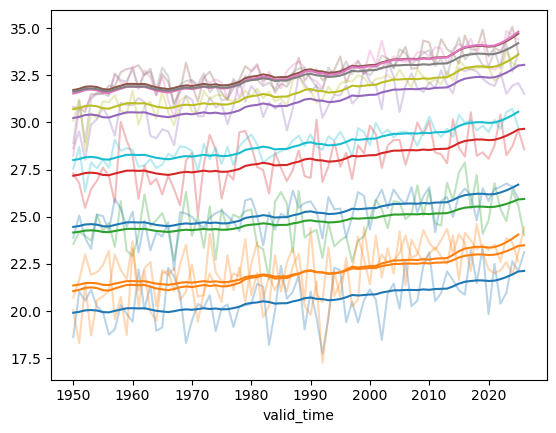

In [16]:
df_ts.plot(alpha = 0.3, legend = None)
ax = plt.gca()
ax.set_prop_cycle(None)

df_fitted.plot(ax = ax, legend = None)